#### What is the forecasted incidence of OHCA till year 2040, based on Pan-Asian Resuscitation Outcomes Study (PAROS) data?

In [1]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import io
import msoffcrypto
import openpyxl

In [ ]:
# environment set up
from dotenv import load_dotenv
import os

# use os.getcwd instead of os.path.dirname(__file__) for jupyter notebooks to get the current working directory
parent_dir = os.path.abspath(os.path.join(os.getcwd(), "../.."))

load_dotenv(os.path.join(parent_dir, ".env"))

False

In [3]:
pd.set_option("display.max_columns", None)

##### read the paros dataset

In [ ]:
filename = "DataExportParos_SG_Apr10-Dec21_with postal codes_27Mar25_encryptedv1.xlsx"
# load password from .env
password = os.getenv("PAROS_PASSWORD")

with open("../../datasets/" + filename, "rb") as encrypted_data:
    paros = msoffcrypto.OfficeFile(encrypted_data)
    paros.load_key(password = password)
    # decrypt file into a BytesIO object
    decrypted = io.BytesIO()
    paros.decrypt(decrypted)

    # use pandas to read the decrypted Excel File
    df = pd.read_excel(decrypted)

/Users/yitong/opt/anaconda3/envs/geopandasNew/lib/python3.9/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Data Validation extension is not supported and will be removed
  for idx, row in parser.parse():


In [13]:
print(df.head())

      Case # Country City  Site # Patient brought in by Date of Incident  \
0  SGSIN0213      SG  SIN       2                   EMS       2010-04-01   
1  SGSIN0218      SG  SIN       2                   EMS       2010-04-01   
2  SGSIN6480      SG  SIN       6                   EMS       2010-04-01   
3  SGSIN5332      SG  SIN       5                   EMS       2010-04-02   
4  SGSIN0214      SG  SIN       2                   EMS       2010-04-03   

   Location of incident Location Unknown        Location Type  \
0              470146.0              NaN       Home Residence   
1              520926.0              NaN       Home Residence   
2              560565.0              NaN  Healthcare Facility   
3              680626.0              NaN       Home Residence   
4              468963.0              NaN  Place of Recreation   

           Location Type Other  Age Age Modifier  Gender     Race  \
0                  HDB Level 7   60        Years    Male  Chinese   
1             

##### OHCA cases year on year

In [9]:
# convert date from 6/4/10 to April 6, 2010. Invalid parising will be set as NaN
df["Date of Incident"] = pd.to_datetime(df["Date of Incident"], dayfirst = True, errors = 'coerce')

# extract year into a new column
df["Year"] = df["Date of Incident"].dt.year

# extract month into a new column
df["Month"] = df["Date of Incident"].dt.to_period("M").astype(str)

# extract quarter into a new column
df["Quarter"] = df["Date of Incident"].dt.to_period("Q").astype(str)

# check if there is any NaN for year and month
check_nan = df[['Year','Month', 'Quarter']].isna().any()
print(check_nan)

Year       False
Month      False
Quarter    False
dtype: bool


In [14]:
# group by year and count entries
OHCA_by_year = df.groupby("Year").size().reset_index(name = "Incident Count (Year)")
print(OHCA_by_year)

OHCA_by_month = df.groupby(["Month"]).size().reset_index(name = "Incident Count (Month)")
# print(OHCA_by_month)

OHCA_by_quarter = df.groupby(["Quarter"]).size().reset_index(name = "Incident Count (Quarter)")
print(OHCA_by_quarter)

    Year  Incident Count (Year)
0   2010                   1081
1   2011                   1377
2   2012                   1440
3   2013                   1736
4   2014                   2038
5   2015                   2372
6   2016                   2505
7   2017                   2841
8   2018                   2975
9   2019                   3233
10  2020                   3431
11  2021                   3636
   Quarter  Incident Count (Quarter)
0   2010Q2                       348
1   2010Q3                       335
2   2010Q4                       398
3   2011Q1                       411
4   2011Q2                       356
5   2011Q3                       331
6   2011Q4                       279
7   2012Q1                       334
8   2012Q2                       354
9   2012Q3                       390
10  2012Q4                       362
11  2013Q1                       458
12  2013Q2                       466
13  2013Q3                       410
14  2013Q4                   

##### Plotting out by year, monthly and quarterly to see if trend exists

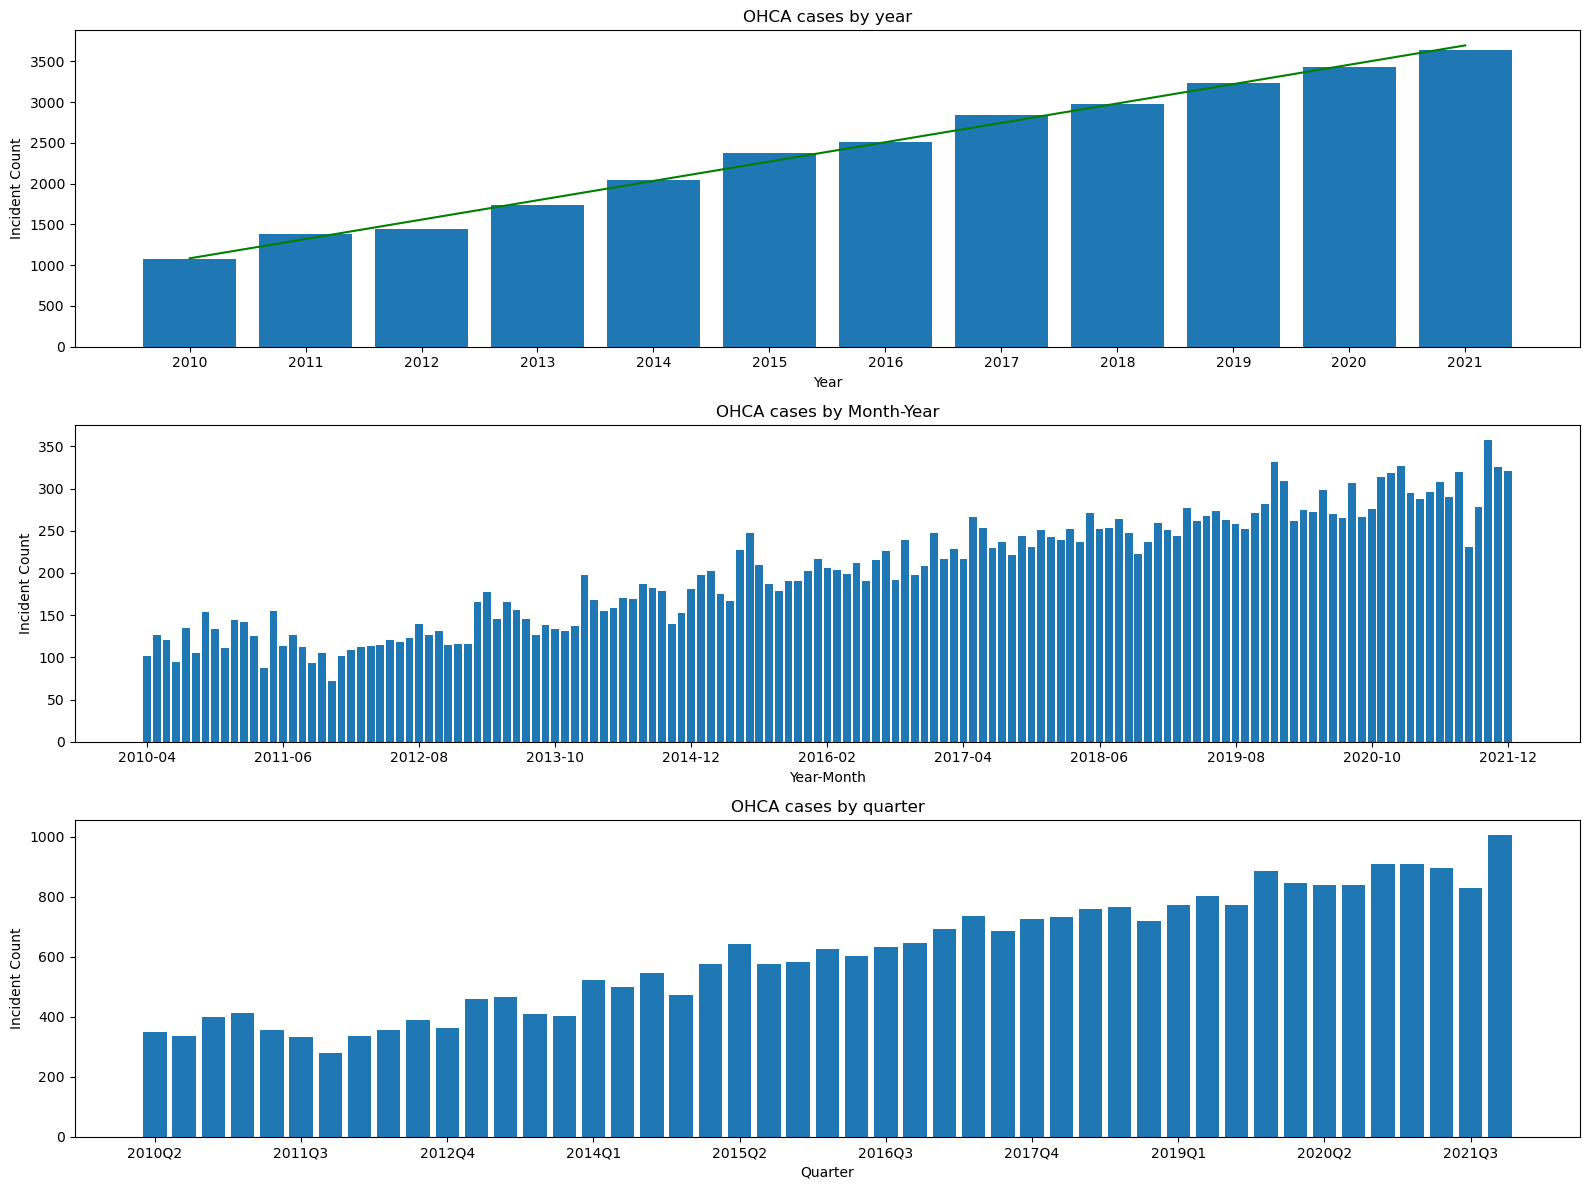

In [15]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize = (16, 12))

## Plot 1: Yearly OHCA
x1_axis = OHCA_by_year["Year"]
y1_axis = OHCA_by_year["Incident Count (Year)"]
ax1.set_xticks(x1_axis)
ax1.bar(x1_axis, y1_axis)

# compute the best-fit line
z1 = np.polyfit(x1_axis, y1_axis, 1) # degree 1 = linear
p1 = np.poly1d(z1)
# plot the best-fit line
ax1.plot(x1_axis, p1(x1_axis), color = "green", linestyle = "-", label = "Trend line")

ax1.set_ylabel("Incident Count")
ax1.set_xlabel("Year")
ax1.set_title("OHCA cases by year")

## Plot 2: Monthly OHCA
x2_axis = OHCA_by_month["Month"]
y2_axis = OHCA_by_month["Incident Count (Month)"]
# have fewer ticks
ax2.set_xticks(range(0, len(x2_axis), max(len(x2_axis)//10, 1)))
ax2.bar(x2_axis, y2_axis)
# ax2.plot(x2_axis, y2_axis, marker = 'o', label = "Monthly Cases")

ax2.set_ylabel("Incident Count")
ax2.set_xlabel("Year-Month")
ax2.set_title("OHCA cases by Month-Year")

## Plot 2: Quarter OHCA
x3_axis = OHCA_by_quarter["Quarter"]
y3_axis = OHCA_by_quarter["Incident Count (Quarter)"]
# have fewer ticks, out of the whole x-axis label, choose every len(x_axis) mod 9 ticks
ax3.set_xticks(range(0, len(x3_axis), max(len(x3_axis)//9, 1)))
ax3.bar(x3_axis, y3_axis)

ax3.set_ylabel("Incident Count")
ax3.set_xlabel("Quarter")
ax3.set_title("OHCA cases by quarter")


plt.tight_layout()
plt.show()

##### Write the above 3 dataframes into csv 

In [ ]:
output_path = "../../datasets/OHCA_incidents_count.csv"
pd.concat([OHCA_by_year, OHCA_by_quarter, OHCA_by_month], axis = 1).to_csv(output_path, index = False)

## <center> Using `prophet` to forecast

In [ ]:
from prophet import Prophet

Importing plotly failed. Interactive plots will not work.


In [8]:
# import the collated incident count csv
OHCA_incident_count = pd.read_csv("../../datasets/OHCA_incidents_count.csv")
OHCA_incident_count.head()

,Year,Incident Count (Year),Quarter,Incident Count (Quarter),Month,Incident Count (Month)
0,2010.0,1081.0,2010Q2,348.0,2010-04,102
1,2011.0,1377.0,2010Q3,335.0,2010-05,126
2,2012.0,1440.0,2010Q4,398.0,2010-06,120
3,2013.0,1736.0,2011Q1,411.0,2010-07,95
4,2014.0,2038.0,2011Q2,356.0,2010-08,135


In [9]:
month_count = OHCA_incident_count[["Month", "Incident Count (Month)"]]

# Rename columns for Prophet
month_count = month_count.rename(columns={"Month": "ds", "Incident Count (Month)": "y"})

# Convert 'ds' to datetime
# date format has to match prophet's month-end format
month_count["ds"] = pd.to_datetime(month_count["ds"]) + pd.offsets.MonthEnd(0)

# split dataset into train and test
# train dataset will be from (2010 - 2019)
# test dataset will be from (2020 - 2021)
train_df = month_count[month_count["ds"].dt.year <= 2019]
test_df = month_count[month_count["ds"].dt.year >= 2020]

print(train_df)
print(test_df)

            ds    y
0   2010-04-30  102
1   2010-05-31  126
2   2010-06-30  120
3   2010-07-31   95
4   2010-08-31  135
..         ...  ...
112 2019-08-31  258
113 2019-09-30  252
114 2019-10-31  271
115 2019-11-30  282
116 2019-12-31  332

[117 rows x 2 columns]
            ds    y
117 2020-01-31  309
118 2020-02-29  261
119 2020-03-31  275
120 2020-04-30  272
121 2020-05-31  298
122 2020-06-30  270
123 2020-07-31  265
124 2020-08-31  307
125 2020-09-30  266
126 2020-10-31  276
127 2020-11-30  314
128 2020-12-31  318
129 2021-01-31  327
130 2021-02-28  295
131 2021-03-31  288
132 2021-04-30  296
133 2021-05-31  308
134 2021-06-30  290
135 2021-07-31  319
136 2021-08-31  231
137 2021-09-30  278
138 2021-10-31  357
139 2021-11-30  326
140 2021-12-31  321


15:44:21 - cmdstanpy - INFO - Chain [1] start processing
15:44:22 - cmdstanpy - INFO - Chain [1] done processing


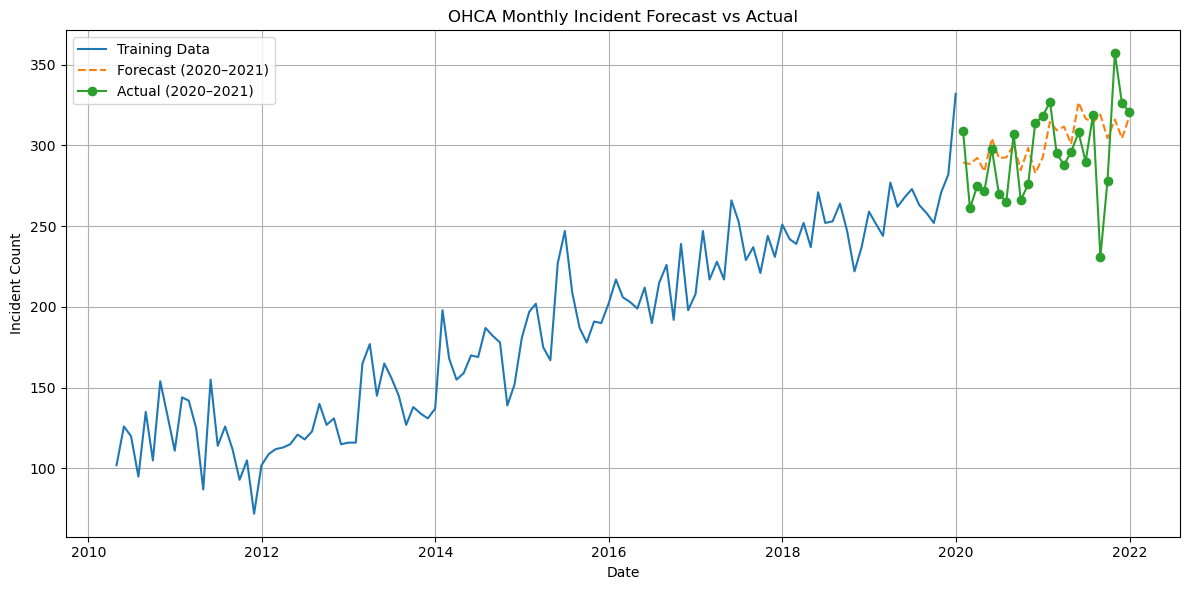

In [10]:
model = Prophet()
model.fit(train_df)

# Make future dataframe and forecast
future_test = model.make_future_dataframe(periods=len(test_df), freq="ME")
forecast_test = model.predict(future_test)

# Merge forecast and actual for test period
comparison = forecast_test[["ds", "yhat"]].tail(len(test_df)).merge(test_df, on='ds', how='left')
# print(comparison)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(train_df['ds'], train_df['y'], label='Training Data')
plt.plot(comparison['ds'], comparison['yhat'], label='Forecast (2020–2021)', linestyle='--')
plt.plot(comparison['ds'], comparison['y'], label='Actual (2020–2021)', marker='o')
plt.title("OHCA Monthly Incident Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Incident Count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
print(comparison[['y', "yhat"]].describe())

                y        yhat
count   24.000000   24.000000
mean   294.458333  302.417064
std     27.783291   12.760531
min    231.000000  282.797803
25%    274.250000  292.260829
50%    295.500000  302.634684
75%    315.000000  314.322213
max    357.000000  326.582085


##### Evaluating the model

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

##### Mean Absolute Error, Root Mean Squared Error and Symmetric Mean Absolute Percentage Error
MAE to tell how off the model is

RMSE to panalise large errors more

SMAPE for relative error (percent based), and some months may have near zero OHCA cases.

##### <center>SMAPE
#### $$\frac{1}{n}\sum_{1}^{n} \frac{|\hat{y}-y|}{y+\hat{y} /2}$$

##### values seemed reasonable for prophet plot

In [13]:
valid_rows = comparison.dropna(subset=['y', "yhat"])

# params: mean_absolute_error(y_true, y_pred)
mae = mean_absolute_error(valid_rows['y'], valid_rows['yhat'])
rmse = np.sqrt(mean_squared_error(valid_rows['y'], valid_rows['yhat']))
smape = 100 * np.mean(
    2 * np.abs(valid_rows['yhat'] - valid_rows['y']) / 
    (np.abs(valid_rows['yhat']) + np.abs(valid_rows['y']))
)


print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"SMAPE: {smape:.2f}%")

MAE: 21.76
RMSE: 27.40
SMAPE: 7.41%


#### Is the residual graph considered acceptable? 

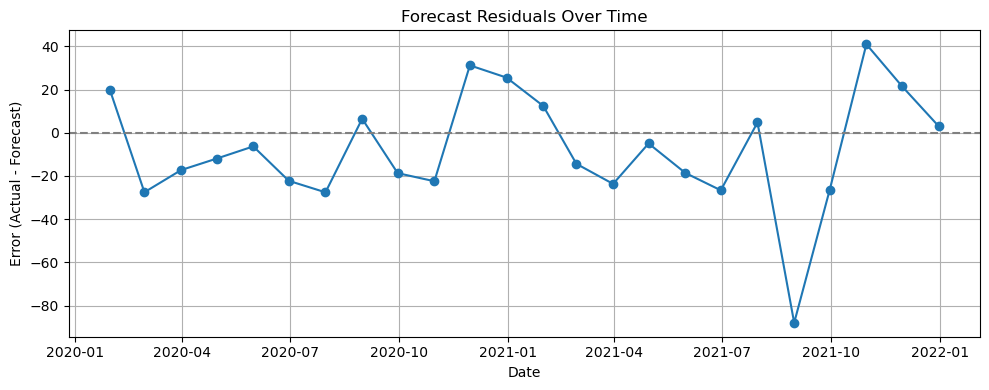

In [14]:
## plot: Residuals (actual - forecast)
comparison['residual'] = comparison['y'] - comparison['yhat']
plt.figure(figsize=(10, 4))
plt.plot(comparison['ds'], comparison["residual"], marker='o')
plt.axhline(0, linestyle='--', color="gray")
plt.title("Forecast Residuals Over Time")
plt.xlabel("Date")
plt.ylabel("Error (Actual - Forecast)")
plt.grid(True)
plt.tight_layout()
plt.show()


#### zooming in on 2021 sept, the outlier forecast residual 

           ds        yhat    y   residual
17 2021-06-30  316.633280  290 -26.633280
18 2021-07-31  314.233881  319   4.766119
19 2021-08-31  318.967878  231 -87.967878
20 2021-09-30  304.468492  278 -26.468492
21 2021-10-31  316.025723  357  40.974277
22 2021-11-30  304.388784  326  21.611216
23 2021-12-31  317.919502  321   3.080498


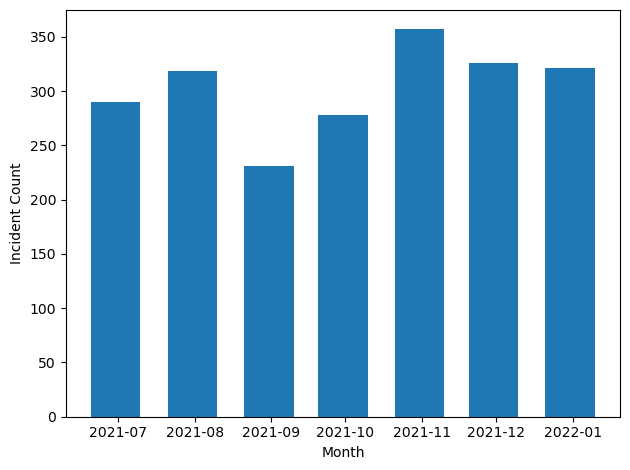

In [15]:
# zooming in on 2021 sept, the outlier forecast residual 
outlier_month = comparison[
    (comparison["ds"] >= "2021-06-01") &
    (comparison["ds"] <= "2021-12-31")
]

print(outlier_month)
plt.bar(outlier_month["ds"], outlier_month["y"], width = 20)
plt.xlabel("Month")
plt.ylabel("Incident Count")
plt.tight_layout()
plt.show()

Prediction till 2040

16:05:16 - cmdstanpy - INFO - Chain [1] start processing
16:05:16 - cmdstanpy - INFO - Chain [1] done processing


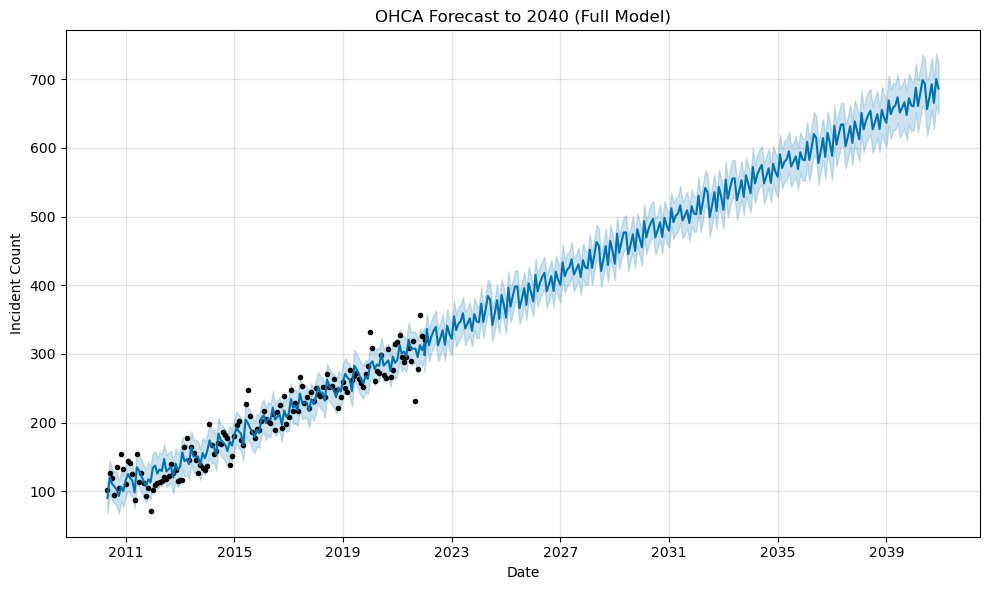

In [17]:
full_df = month_count.copy()
model_full = Prophet()
model_full.fit(full_df)

years_to_forecast = 2040 - 2021
months_to_forecast = years_to_forecast * 12

future_df = model_full.make_future_dataframe(periods = months_to_forecast, freq = "MS") # MS: Month start
# predict future
forecast_full = model_full.predict(future_df)

# plot 
fig = model_full.plot(forecast_full)
plt.title("OHCA Forecast to 2040 (Full Model)")
plt.xlabel("Date")
plt.ylabel("Incident Count")
plt.tight_layout()
plt.show()

#### Next model to try out, SARIMA. Still incomplete

In [31]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
OHCA_incident_count = pd.read_csv("../../datasets/OHCA_incidents_count.csv")
OHCA_incident_count.head(15)

,Year,Incident Count (Year),Quarter,Incident Count (Quarter),Month,Incident Count (Month)
0,2010.0,1081.0,2010Q2,348.0,2010-04,102
1,2011.0,1377.0,2010Q3,335.0,2010-05,126
2,2012.0,1440.0,2010Q4,398.0,2010-06,120
3,2013.0,1736.0,2011Q1,411.0,2010-07,95
4,2014.0,2038.0,2011Q2,356.0,2010-08,135
5,2015.0,2372.0,2011Q3,331.0,2010-09,105
6,2016.0,2505.0,2011Q4,279.0,2010-10,154
7,2017.0,2841.0,2012Q1,334.0,2010-11,133
8,2018.0,2975.0,2012Q2,354.0,2010-12,111
9,2019.0,3233.0,2012Q3,390.0,2011-01,144


##### Extract monthly incidences

     Month  Incident Count (Month)
0  2010-04                     102
1  2010-05                     126
2  2010-06                     120
3  2010-07                      95
4  2010-08                     135


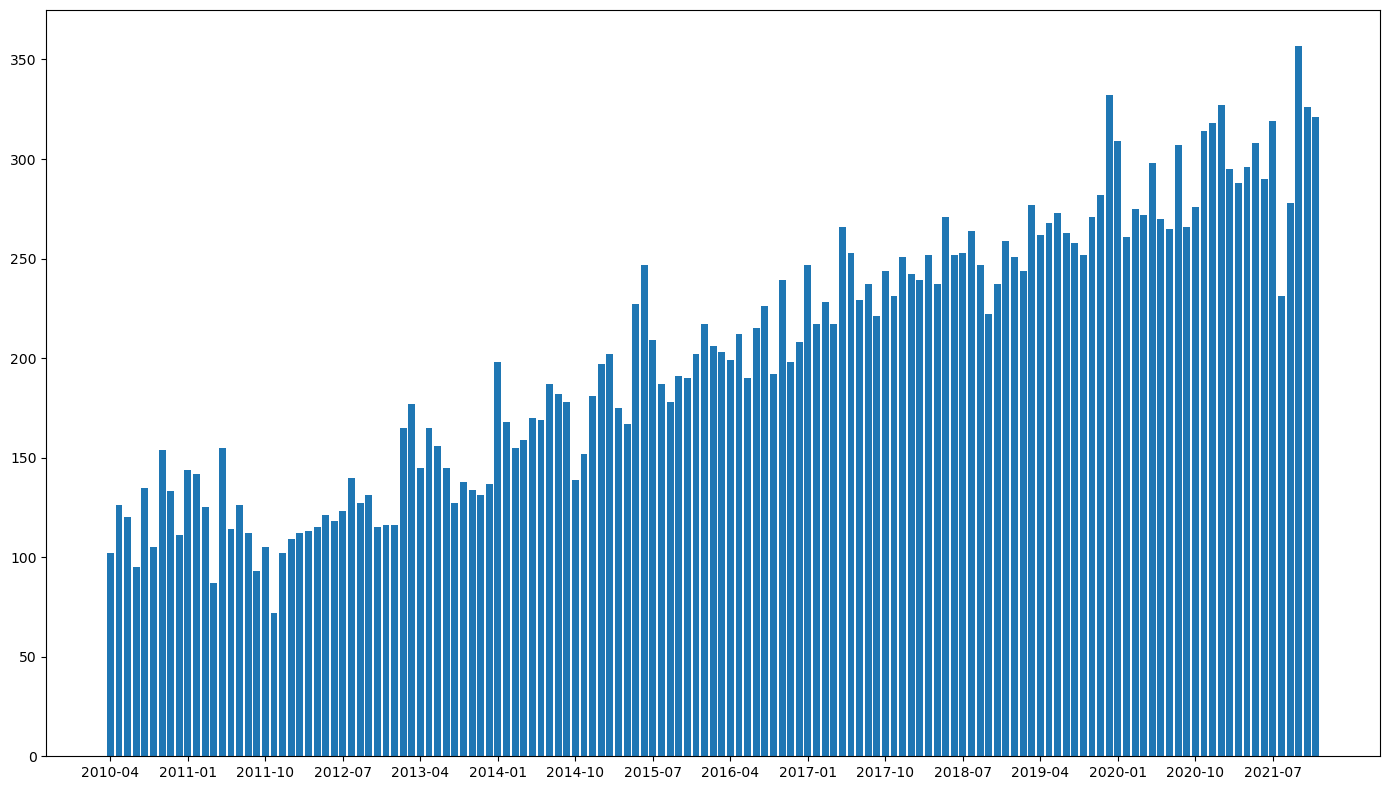

In [ ]:
count_by_month = OHCA_incident_count[["Month", "Incident Count (Month)"]].copy()
print(count_by_month.head())

plt.figure(figsize = (14, 8))
plt.bar(count_by_month["Month"], count_by_month["Incident Count (Month)"])

# Set x-ticks at regular intervals (e.g., every 3rd label)
interval = 9
xticks = count_by_month["Month"][::interval]
plt.xticks(ticks=range(0, len(count_by_month["Month"]), interval), labels=xticks)


plt.tight_layout()
plt.show()

##### Checking Stationarity before applying SARIMA
https://www.analyticsvidhya.com/blog/2018/09/an-introduction-to-non-stationary-time-series-in-python/

- Performing the ADF test
- Performing KPSS test

In [132]:
import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning

def check_stationarity_adf(timeseries):
    # perform Augmented Dickey-Fuller test
    print("ADF result")
    result = adfuller(timeseries, autolag = "AIC")
    # print(result)
    p_value = result[1]
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {p_value}')
    print('Stationary' if p_value < 0.05 else 'Non-Stationary')

check_stationarity_adf(count_by_month["Incident Count (Month)"])

print()

def check_stationarity_kpss(timeseries):
    print("KPSS result")
    # to supress the warning
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category = InterpolationWarning)
        kpss_result = kpss(timeseries, regression='c', nlags='auto')
    # print(kpss_result)
    p_value = kpss_result[1]
    print(f"KPSS statistic: {kpss_result[0]}")
    print(f"p-value: {p_value}")
    print("Stationary" if p_value > 0.05 else "Non-stationary")

check_stationarity_kpss(count_by_month["Incident Count (Month)"])

ADF result
ADF Statistic: 0.49307726866654616
p-value: 0.9846611596956756
Non-Stationary

KPSS result
KPSS statistic: 1.65269712311951
p-value: 0.01
Non-stationary


#### The monthly incident data is non-stationary as determined by AFG and KPSS testing. Will need to change it to stationary.

##### Using Seasonal Differencing: $y_{t}^{'} = y_{t} - y_{(t-n)}$
n = 12, months in a year

##### Using differencing: $y_{t}^{'} = y_{t} - y_{t-1}$

##### And using log transformation

In [133]:
## seasonal differencing (12 months period)
# print(count_by_month.describe())

n = 12
count_by_month["seasonal_differencing"] = count_by_month["Incident Count (Month)"] - count_by_month["Incident Count (Month)"].shift(n)
season_differencing = count_by_month["seasonal_differencing"].dropna()
print(season_differencing.describe())

print()
## differencing
count_by_month["differencing"] = count_by_month["Incident Count (Month)"] - count_by_month["Incident Count (Month)"].shift(1)
differencing = count_by_month["differencing"].dropna()
print(differencing.describe())

count    129.000000
mean      16.620155
std       26.922979
min      -76.000000
25%        4.000000
50%       16.000000
75%       31.000000
max       82.000000
Name: seasonal_differencing, dtype: float64

count    140.000000
mean       1.564286
std       25.615084
min      -88.000000
25%      -15.000000
50%        0.500000
75%       13.250000
max       79.000000
Name: differencing, dtype: float64


Since the PAROS dataset shows an increase in number of incidences, a `log` transformation will be used to stabilise the trend. 

In [147]:
## log transformation
log_series = np.log(count_by_month["Incident Count (Month)"])
# print(log_series)

log_diff_series = log_series.diff().dropna()
log_diff_series.index = pd.to_datetime(count_by_month["Month"].iloc[1:])
print(log_diff_series.head())
# print(log_diff_series.isna().any())

log_seasonal_diff_series = log_series.diff(12).dropna()
print(log_seasonal_diff_series.isna().any())
# print(log_seasonal_diff_series.describe())

Month
2010-05-01    0.211309
2010-06-01   -0.048790
2010-07-01   -0.233615
2010-08-01    0.351398
2010-09-01   -0.251314
Name: Incident Count (Month), dtype: float64
False


##### checking stationarity again
Seems that both the log and non-log differencing made the dataset stationary

In [112]:
## check stationarity again
check_stationarity_adf(season_differencing)
check_stationarity_kpss(season_differencing)

print()

check_stationarity_adf(differencing)
check_stationarity_kpss(differencing)

print()

check_stationarity_adf(log_seasonal_diff_series)
check_stationarity_kpss(log_seasonal_diff_series)

print()

check_stationarity_adf(log_diff_series)
check_stationarity_kpss(log_diff_series)

ADF result
ADF Statistic: -6.491202661512486
p-value: 1.2254110664553253e-08
Stationary
KPSS result
KPSS statistic: 0.26708952474637354
p-value: 0.1
Stationary

ADF result
ADF Statistic: -6.816467590852463
p-value: 2.0531492789904676e-09
Stationary
KPSS result
KPSS statistic: 0.41359794967507685
p-value: 0.07129398720901861
Stationary

ADF result
ADF Statistic: -4.1220654594377555
p-value: 0.0008903077419367989
Stationary
KPSS result
KPSS statistic: 0.15674020753349988
p-value: 0.1
Stationary

ADF result
ADF Statistic: -6.195528111930951
p-value: 5.97836470731238e-08
Stationary
KPSS result
KPSS statistic: 0.1281955086008389
p-value: 0.1
Stationary


Now that the data is stationary, we can start with the SARIMA analysis

https://www.geeksforgeeks.org/machine-learning/sarima-seasonal-autoregressive-integrated-moving-average/

- First identify model parameters

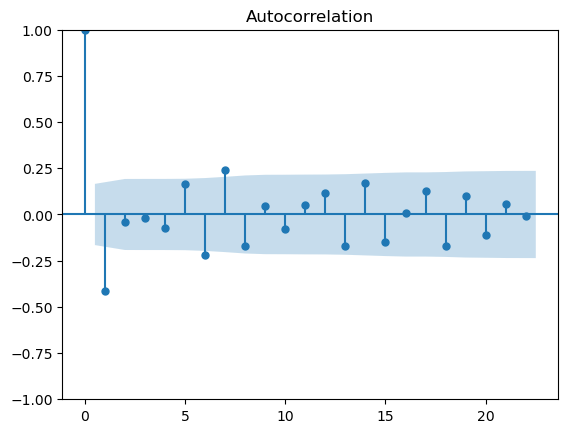

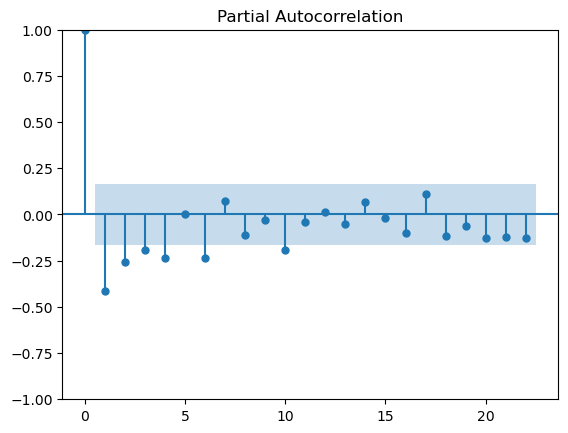

In [113]:
# Autocorrelation Plot
plot_acf(log_diff_series)
# Partial autocorrelation Plot
plot_pacf(log_diff_series)

plt.show()

The SARIMA parameters will be set to the "default" first:

p, d, q, P, D, Q all 1

s = 12 (months)

In [148]:
# defining the params for SARIMA
p, d, q = 0, 0, 0
P, D, Q, s = 1, 1, 1, 12

sarima_model = SARIMAX(log_diff_series, order = (p, d, q), seasonal_order = (P, D, Q, s))
results = sarima_model.fit()
sarima_model

/Users/yitong/opt/anaconda3/envs/geopandasNew/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/yitong/opt/anaconda3/envs/geopandasNew/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f= -3.57448D-01    |proj g|=  4.83636D+00

At iterate    5    f= -4.21842D-01    |proj g|=  1.09626D-01

At iterate   10    f= -4.33638D-01    |proj g|=  1.26820D-01

At iterate   15    f= -4.36444D-01    |proj g|=  5.48117D-01

At iterate   20    f= -4.52104D-01    |proj g|=  2.54602D-01

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    3     25     68      2     0     0   6.328D-04  -4.529D-01
  F = -0.45293926432334197     

ABNORMA


 Bad direction in the line search;
   refresh the lbfgs memory and restart the iteration.
/Users/yitong/opt/anaconda3/envs/geopandasNew/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "

 Line search cannot locate an adequate point after MAXLS
  function and gradient evaluations.
  Previous x, f and g restored.
 Possible causes: 1 error in function or gradient evaluation;
                  2 rounding error dominate computation.


In [ ]:
from sklearn.metrics import mean_absolute_percentage_error
